In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

data = pd.read_csv("A2data.tsv", sep="\t")
data = data.iloc[:, 1:]
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

cv = LeaveOneOut()
baseline_model = LinearRegression()
baseline_scores = -cross_val_score(baseline_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
baseline_mean_rmse = baseline_scores.mean()
baseline_std_rmse = baseline_scores.std()

print("Linear Regression Mean RMSE:", baseline_mean_rmse)
print("Linear Regression Std RMSE:", baseline_std_rmse)


Linear Regression Mean RMSE: 2.167030131925381
Linear Regression Std RMSE: 1.7331601633825726


Task 1 uses Linear Regression as the baseline model because it is the simplest regression method covered in the course and can be applied directly to the raw dataset without preprocessing or feature selection.

Since the dataset contains only 48 observations, Leave-One-Out cross-validation was selected so that each iteration uses 47 observations for training and 1 for testing.

The baseline model achieved an RMSE of approximately 1.352.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaled_model = Pipeline([("scaler", StandardScaler()),("linear_regression", LinearRegression())])
scaled_scores = -cross_val_score(scaled_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
scaled_mean_rmse = scaled_scores.mean()
scaled_std_rmse = scaled_scores.std()

print("Scaled Linear Regression Mean RMSE:", scaled_mean_rmse)
print("Scaled Linear Regression Std RMSE:", scaled_std_rmse)

Decision Tree Mean RMSE: 0.7388148370726496
Decision Tree Std RMSE: 0.5113892808087753


Task 2 applies feature scaling before Linear Regression. Standardization places all features on a comparable scale while keeping the regression model unchanged.

This reduced the RMSE compared with the baseline model, showing that preprocessing alone improves predictive performance.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_scores = -cross_val_score(tree_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
tree_mean_rmse = tree_scores.mean()
tree_std_rmse = tree_scores.std()

print("Decision Tree Mean RMSE:", tree_mean_rmse)
print("Decision Tree Std RMSE:", tree_std_rmse)



Scaled Linear Regression Mean RMSE: 1.8641389571734177
Scaled Linear Regression Std RMSE: 1.845091815516713


Then uses Decision Tree Regression as a non-linear alternative model. Tree-based methods can capture patterns that linear models may not represent well.

The RMSE is lower than both linear regression models, indicating that non-linear relationships are present in the dataset.

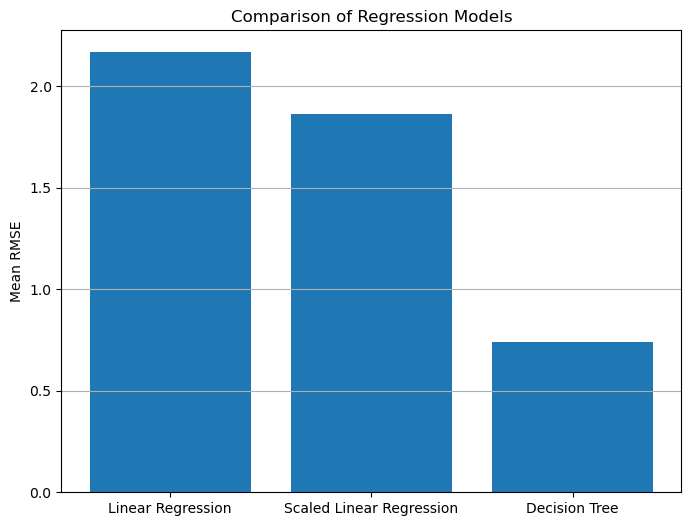

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.bar(
    ["Linear Regression", "Scaled Linear Regression", "Decision Tree"],
    [baseline_mean_rmse, scaled_mean_rmse, tree_mean_rmse]
)

plt.ylabel("Mean RMSE")
plt.title("Comparison of Regression Models")
plt.grid(axis='y')

plt.show()




The bar chart compares the mean RMSE values across the three models. Linear Regression produced the highest prediction error, while scaling improved performance moderately. Decision Tree Regression achieved the lowest RMSE and therefore provided the strongest predictive performance.


Among the tested models, Decision Tree Regression produced the lowest prediction error. This suggests that adding model flexibility improves performance more than preprocessing alone.